# Experiment 1: agreement counts, candidate logits, and optional reasoning

This notebook compares the two `XVsYPosteriorProbe.reasoning` settings, `False` and `True`, over the same exhaustive noisy-channel evidence scenarios. With positional control enabled, every scenario is shown in both candidate orders. Each model therefore receives exactly $2 \times 10 \times 2^3 \times 2 = 320$ inference rows. `ENABLE_MTP` is the single top-level switch for using native MTP as the continuous completion backend.

Each row uses one continuous assistant generation. With reasoning off, the user message ends in `ANSWER:` and the chat template then opens the assistant turn at the answer value. With reasoning on, the user message ends in `REASONING:` and the unmodified assistant completion must eventually contain a terminal `ANSWER:{candidate}`. The runner stores the full completion and exact generated token IDs, locates the actual answer boundary, and teacher-forces the exact generated sequence for answer-boundary logits and activation capture. Missing or malformed answers remain in the dataset as compliance observations; they are never repaired.


In [13]:
from __future__ import annotations

import csv
import gc
import hashlib
import html
import logging
import math
import os
import re
import sys
import threading
from collections import Counter, defaultdict
from contextlib import contextmanager
from datetime import datetime, timezone
from pathlib import Path
from statistics import correlation, fmean, median, pstdev
from time import monotonic

# This must be set before importing third-party packages such as Transformers,
# which may import torchao while probing optional quantization backends.
os.environ.setdefault("TORCHAO_FORCE_SKIP_LOADING_SO_FILES", "1")
logging.getLogger("torchao").setLevel(logging.ERROR)

import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from transformers import AutoProcessor

REPO_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
sys.path.insert(0, str(REPO_ROOT))

from mats_experiments.noisy_channel_bayesian import (
    CaptureSpec,
    ExecutionConfig,
    MetricSpec,
    ModelConfig,
    NoisyChannelBayesianEnvironment,
    QwenRunner,
    RandomSubsetQuestion,
    SGLangMTPConfig,
    SystemPrompt,
    TokenizerBinding,
    TranscriptDataset,
    TranscriptDatasetGenerator,
    XVsYPosteriorProbe,
    answer_patterns,
    get_answer_surface_logits,
)


## Configuration

`MODEL_SELECTION` accepts one model ID or a list. The question seed and schedules are shared across models and across the two reasoning settings. `MAX_COMPLETION_TOKENS` is a watchdog for a continuous generation; generation normally stops at the tokenizer or model assistant-end token. It is not an experimental reasoning parameter.


In [14]:
N = 8
K = 3
R_VALUES = "9/10"
NUM_QUESTION_SETS = 10
CONTROL_POSITIONAL_BIAS = True
REASONING_VALUES = (False, True)
ENABLE_MTP = False  # Applies to the complete, single-pass generation for every row.

SYSTEM_PROMPT_TEXT = (
    "You are a Bayesian reasoner. Follow the user's game rules exactly. "
    "Use plaintext only. Do not use Markdown, headings, bullets, tables, code blocks, "
    "HTML, or any other formatting."
)
MODEL_SELECTION: str | list[str] = ["Qwen/Qwen3.5-4B", "Qwen/Qwen3.5-9B"]

X = 2
Y = 7
SUBSET_SIZE = 4
SEED = 20260902

MODEL_DTYPE = "auto"
DEVICE_MAP = None
LOCAL_FILES_ONLY = True
RUN_MODEL = True
MAX_COMPLETION_TOKENS = 4096
CHECKPOINT_EVERY_BATCHES = 25
LOG_INTERVAL_SECONDS = 30
EXPERIMENT_ROOT = REPO_ROOT / "artifacts" / "noisy_channel_bayesian_experiment_1"

SGLANG_PYTHON = REPO_ROOT / ".venv-sglang" / "bin" / "python"
COMPLETION_MTP_BY_MODEL = {
    "Qwen/Qwen3.5-4B": SGLangMTPConfig(
        enabled=ENABLE_MTP, python_executable=SGLANG_PYTHON,
        speculative_num_steps=3, speculative_eagle_topk=1,
        speculative_num_draft_tokens=4, context_length=8192,
        cuda_graph_max_batch_size=48,
    ),
    "Qwen/Qwen3.5-9B": SGLangMTPConfig(
        enabled=ENABLE_MTP, python_executable=SGLANG_PYTHON,
        speculative_num_steps=3, speculative_eagle_topk=1,
        speculative_num_draft_tokens=4, context_length=8192,
        cuda_graph_max_batch_size=24,
    ),
}
DEFAULT_COMPLETION_MTP = SGLangMTPConfig(
    enabled=ENABLE_MTP, python_executable=SGLANG_PYTHON, context_length=8192,
)
RUN_ID = (
    "agreement_logits_terminal_candidate_boundary_v3_"
    + ("mtp" if ENABLE_MTP else "transformers")
)
BATCH_SIZES_BY_MODEL = {
    "Qwen/Qwen3.5-4B": {"completion": 40, "capture": 4, "score": 16},
    "Qwen/Qwen3.5-9B": {"completion": 24, "capture": 2, "score": 8},
}
DEFAULT_BATCH_SIZES = {"completion": 4, "capture": 1, "score": 4}


In [15]:
def log_progress(message: str) -> None:
    timestamp = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    print(f"[{timestamp}] {message}", flush=True)


def checkpoint_row_count(path: Path) -> int:
    if not path.exists():
        return 0
    try:
        with path.open("r", encoding="utf-8") as handle:
            return sum(bool(line.strip()) for line in handle)
    except OSError:
        return 0


@contextmanager
def progress_heartbeat(label: str, checkpoint_path: Path | None = None):
    started = monotonic()
    stopped = threading.Event()

    def report() -> None:
        while not stopped.wait(LOG_INTERVAL_SECONDS):
            suffix = ""
            if checkpoint_path is not None:
                suffix = (
                    f"; completed rows={checkpoint_row_count(checkpoint_path)}/"
                    f"{EXPECTED_INFERENCE_ROWS_PER_MODEL}"
                )
            log_progress(
                f"{label}: still running; elapsed={(monotonic() - started) / 60:.1f} min"
                f"{suffix}"
            )

    log_progress(f"{label}: started")
    worker = threading.Thread(target=report, name=f"{label}-heartbeat", daemon=True)
    worker.start()
    succeeded = False
    try:
        yield
        succeeded = True
    finally:
        stopped.set()
        worker.join(timeout=1)
        status = "finished" if succeeded else "stopped with an error"
        log_progress(f"{label}: {status} after {(monotonic() - started) / 60:.1f} min")


def normalize_model_ids(selection: str | list[str]) -> list[str]:
    values = [selection] if isinstance(selection, str) else list(selection)
    if not values or not all(isinstance(value, str) and value.strip() for value in values):
        raise ValueError("MODEL_SELECTION must contain non-empty model IDs.")
    if len(values) != len(set(values)):
        raise ValueError("MODEL_SELECTION contains a duplicate model ID.")
    return values


def model_key(model_id: str) -> str:
    readable = re.sub(r"[^A-Za-z0-9_.-]+", "_", model_id).strip("_")
    digest = hashlib.sha256(model_id.encode()).hexdigest()[:8]
    return f"{readable}_{digest}"


MODEL_IDS = normalize_model_ids(MODEL_SELECTION)
environment = NoisyChannelBayesianEnvironment(
    n=N, k=K, r_values=R_VALUES, control_positional_bias=CONTROL_POSITIONAL_BIAS
)
question = RandomSubsetQuestion(subset_size=SUBSET_SIZE, replacement=False, sort=True)
probes = tuple(
    XVsYPosteriorProbe(
        x=X, y=Y, reasoning=reasoning, allow_same=False,
        call_layout="conversation",
    )
    for reasoning in REASONING_VALUES
)
system_prompt = SystemPrompt(SYSTEM_PROMPT_TEXT)
metric_spec = MetricSpec(sequence_scores=False)
capture_spec = CaptureSpec(
    logits_boundaries=("answer",),
    logits_scope="answer_surfaces",
    streams=("resid_post",),
    layers="all",
    tokens="all",
    every_decode_position=False,
)

assert tuple(probe.reasoning for probe in probes) == REASONING_VALUES
assert all((probe.x, probe.y, probe.allow_same) == (X, Y, False) for probe in probes)
assert all(config.enabled is ENABLE_MTP for config in COMPLETION_MTP_BY_MODEL.values())
assert DEFAULT_COMPLETION_MTP.enabled is ENABLE_MTP
assert environment.shared_reliability and CONTROL_POSITIONAL_BIAS
EXPECTED_INFERENCE_ROWS_PER_MODEL = (
    len(REASONING_VALUES) * NUM_QUESTION_SETS * 2**K * 2
)
assert EXPECTED_INFERENCE_ROWS_PER_MODEL == 320
print({
    "models": MODEL_IDS,
    "reasoning_values": REASONING_VALUES,
    "mtp_enabled": ENABLE_MTP,
    "evidence_scenarios_per_reasoning_value": NUM_QUESTION_SETS * 2**K,
    "inference_rows_per_model": EXPECTED_INFERENCE_ROWS_PER_MODEL,
    "reliability": str(environment.reliabilities[0]),
    "artifact_root": str(EXPERIMENT_ROOT),
})


{'models': ['Qwen/Qwen3.5-4B', 'Qwen/Qwen3.5-9B'], 'reasoning_values': (False, True), 'mtp_enabled': False, 'evidence_scenarios_per_reasoning_value': 80, 'inference_rows_per_model': 320, 'reliability': '9/10', 'artifact_root': '/workspace/MATS/artifacts/noisy_channel_bayesian_experiment_1'}


## Agreement fields and paired prompt validation

For candidate $c$, agreement is 1 when the report equals the truthful YES/NO answer predicted by $c$. The two reasoning variants share the same observations, candidate order, answer rules, and parameter substitutions. Their prompt bodies are identical through the permitted-values sentence; only the final behavior instruction and boundary differ.


In [16]:
def question_schedules(
    dataset: TranscriptDataset, reasoning: bool
) -> list[list[list[int]]]:
    return [
        next(
            row for row in dataset
            if row["question_set_index"] == index and row["reasoning"] is reasoning
        )["membership_sets"]
        for index in range(NUM_QUESTION_SETS)
    ]


def validate_exhaustive_dataset(dataset: TranscriptDataset) -> None:
    expected_patterns = [
        "".join("Y" if value == "YES" else "N" for value in pattern)
        for pattern in answer_patterns(K)
    ]
    assert len(dataset) == EXPECTED_INFERENCE_ROWS_PER_MODEL
    assert dataset.manifest["probe_parameter_count"] == 2
    assert tuple(dataset.manifest["reasoning_values"]) == REASONING_VALUES
    assert dataset.manifest["num_question_sets"] == NUM_QUESTION_SETS
    assert dataset.manifest["presentations_per_scenario"] == 2
    assert all(row["n"] == N and row["k"] == K for row in dataset)
    assert all(row["candidate_1"] == X and row["candidate_2"] == Y for row in dataset)
    assert all(
        row["messages"][0] == {"role": "system", "content": SYSTEM_PROMPT_TEXT}
        for row in dataset
    )
    schedules = {}
    for probe_index, reasoning in enumerate(REASONING_VALUES):
        selected = [row for row in dataset if row["reasoning"] is reasoning]
        assert len(selected) == NUM_QUESTION_SETS * 2**K * 2
        assert all(row["probe_parameter_index"] == probe_index for row in selected)
        schedules[reasoning] = question_schedules(dataset, reasoning)
        for question_set_index in range(NUM_QUESTION_SETS):
            rows = [
                row for row in selected
                if row["question_set_index"] == question_set_index
            ]
            assert [row["answer_pattern"] for row in rows] == [
                pattern for pattern in expected_patterns for _ in range(2)
            ]
    assert schedules[False] == schedules[True]

    paired = defaultdict(dict)
    for row in dataset:
        key = (
            row["question_set_index"], row["answer_pattern_index"],
            row["presentation_order"], tuple(row["candidate_value_order"]),
        )
        paired[key][bool(row["reasoning"])] = row
    assert len(paired) == NUM_QUESTION_SETS * 2**K * 2
    assert all(set(pair) == {False, True} for pair in paired.values())
    for pair in paired.values():
        off_row, on_row = pair[False], pair[True]
        fixed_fields = (
            "n", "k", "reliabilities_exact", "question_set_index",
            "answer_pattern_index", "answer_pattern", "questions",
            "membership_sets", "observed_reports", "candidate_1",
            "candidate_2", "presentation_index", "presentation_order",
            "candidate_value_order", "x", "y", "allow_same",
            "call_layout", "answer_prefix",
        )
        assert all(off_row[field] == on_row[field] for field in fixed_fields)
        permitted_line = (
            f"The permitted values are {off_row['x']}, {off_row['y']}."
        )
        off = off_row["messages"][-1]["content"]
        on = on_row["messages"][-1]["content"]
        off_prefix, off_separator, _ = off.partition(permitted_line)
        on_prefix, on_separator, _ = on.partition(permitted_line)
        assert off_separator == on_separator == permitted_line
        assert off_prefix == on_prefix
        tie_line = (
            f"If the two posterior probabilities are equal, output either "
            f"{off_row['x']} or {off_row['y']}; either value is valid."
        )
        assert tie_line in off and tie_line in on
        assert off.endswith("ANSWER:")
        assert on.endswith("\nREASONING:\n")
        assert "at most" not in on
        assert " | " not in on + off


def print_serialized_prompt_pair(
    dataset: TranscriptDataset, *, model_id: str
) -> None:
    example_rows = [
        row for row in dataset
        if row["question_set_index"] == 0
        and row["answer_pattern_index"] == 0
        and row["presentation_order"] == "C1_C2"
        and tuple(row["candidate_value_order"]) == (X, Y)
    ]
    by_reasoning = {bool(row["reasoning"]): row for row in example_rows}
    assert len(example_rows) == 2 and set(by_reasoning) == {False, True}
    off_row, on_row = by_reasoning[False], by_reasoning[True]
    fixed_fields = (
        "n", "k", "reliabilities_exact", "question_set_index",
        "answer_pattern_index", "answer_pattern", "questions",
        "membership_sets", "observed_reports", "candidate_1",
        "candidate_2", "presentation_index", "presentation_order",
        "candidate_value_order", "x", "y", "allow_same",
        "call_layout", "answer_prefix",
    )
    assert all(off_row[field] == on_row[field] for field in fixed_fields)

    print("\n" + "=" * 100)
    print(f"PAIRED SERIALIZED PROMPT EXAMPLE: {model_id}")
    print({
        "question_set_index": off_row["question_set_index"],
        "answer_pattern_index": off_row["answer_pattern_index"],
        "answer_pattern": off_row["answer_pattern"],
        "presentation_order": off_row["presentation_order"],
        "candidate_value_order": off_row["candidate_value_order"],
        "membership_sets": off_row["membership_sets"],
        "observed_reports": off_row["observed_reports"],
    })
    for reasoning in REASONING_VALUES:
        print(f"\n--- reasoning={reasoning} serialized_prompt ---")
        print(by_reasoning[reasoning]["serialized_prompt"])
    print("=" * 100)


## Generate once, then probe the actual answer boundary

The reasoning-on completion is left untouched. The runner finds the last `ANSWER:` marker and records its exact generated-token boundary. With reasoning off, `ANSWER:` is the end of the user message and the answer boundary includes the assistant-role tokens added by the chat template. A teacher-forced forward pass uses the exact prompt IDs plus the exact emitted sequence IDs (including an emitted stop token when available) to capture residual-stream activations and candidate logits. Rows with no usable boundary retain their completion and compliance failure but have missing answer-boundary logits.


In [17]:
datasets_by_model: dict[str, TranscriptDataset] = {}
results_by_model: dict[str, list[dict[str, object]]] = {}
balanced_results_by_model: dict[str, list[dict[str, object]]] = {}
run_dirs_by_model: dict[str, Path] = {}


def optional_mean(values: list[float | None]) -> float | None:
    return fmean(value for value in values if value is not None) if all(
        value is not None for value in values
    ) else None


def balance_positional_pairs(rows: list[dict[str, object]]) -> list[dict[str, object]]:
    pairs = defaultdict(list)
    for row in rows:
        pairs[row["positional_control_pair_id"]].append(row)
    balanced_rows = []
    invariants = (
        "reasoning", "probe_parameter_index", "question_set_index",
        "answer_pattern_index", "answer_pattern", "membership_sets",
        "observed_reports", "total_agreement_candidate_1",
        "total_agreement_candidate_2", "agreement_candidate_1_by_question",
        "agreement_candidate_2_by_question",
    )
    for pair_id, pair in pairs.items():
        by_order = {row["presentation_order"]: row for row in pair}
        assert set(by_order) == {"C1_C2", "C2_C1"}
        first, second = by_order["C1_C2"], by_order["C2_C1"]
        for field in invariants:
            assert first[field] == second[field], (pair_id, field)
        c1_values = [first["candidate_1_raw_logit"], second["candidate_1_raw_logit"]]
        c2_values = [first["candidate_2_raw_logit"], second["candidate_2_raw_logit"]]
        difference_values = [
            first["candidate_1_minus_candidate_2_raw_logit"],
            second["candidate_1_minus_candidate_2_raw_logit"],
        ]
        difference_first, difference_second = difference_values
        balanced = dict(first)
        balanced.update({
            "balanced_across_presentation_order": True,
            "candidate_1_raw_logit_order_c1_c2": c1_values[0],
            "candidate_1_raw_logit_order_c2_c1": c1_values[1],
            "candidate_2_raw_logit_order_c1_c2": c2_values[0],
            "candidate_2_raw_logit_order_c2_c1": c2_values[1],
            "candidate_1_raw_logit": optional_mean(c1_values),
            "candidate_2_raw_logit": optional_mean(c2_values),
            "candidate_1_minus_candidate_2_raw_logit": optional_mean(difference_values),
            "position_effect_on_candidate_difference": (
                0.5 * (float(difference_first) - float(difference_second))
                if difference_first is not None and difference_second is not None else None
            ),
            "pair_has_answer_boundary_logits": all(
                value is not None for value in difference_values
            ),
            "strict_answer_compliance_by_order": {
                order: bool(row["strict_answer_compliance"])
                for order, row in by_order.items()
            },
            "reasoning_length_tokens_by_order": {
                order: row["reasoning_length_tokens"] for order, row in by_order.items()
            },
            "completion_by_order": {
                order: row["full_completion"] for order, row in by_order.items()
            },
            "generated_token_ids_by_order": {
                order: row["generated_token_ids"] for order, row in by_order.items()
            },
            "presentation_artifacts": {
                order: {
                    key: row.get(key)
                    for key in ("row_id", "logit_path", "activation_path")
                }
                for order, row in by_order.items()
            },
        })
        balanced_rows.append(balanced)
    balanced_rows.sort(key=lambda row: (
        bool(row["reasoning"]), int(row["question_set_index"]),
        int(row["answer_pattern_index"]),
    ))
    assert len(balanced_rows) == len(REASONING_VALUES) * NUM_QUESTION_SETS * 2**K
    return balanced_rows


reference_schedules = None
for model_index, model_id in enumerate(MODEL_IDS, start=1):
    sizes = BATCH_SIZES_BY_MODEL.get(model_id, DEFAULT_BATCH_SIZES)
    log_progress(f"Model {model_index}/{len(MODEL_IDS)} {model_id}: loading tokenizer")
    processor = AutoProcessor.from_pretrained(
        model_id, trust_remote_code=False, local_files_only=LOCAL_FILES_ONLY,
    )
    tokenizer = getattr(processor, "tokenizer", processor)
    binding = TokenizerBinding(tokenizer, enable_thinking=False)
    dataset = TranscriptDatasetGenerator(
        environment=environment,
        question=question,
        probe=probes,
        tokenizer_binding=binding,
        system_prompt=system_prompt,
        seed=SEED,
    ).generate(num_question_sets=NUM_QUESTION_SETS)
    validate_exhaustive_dataset(dataset)
    print_serialized_prompt_pair(dataset, model_id=model_id)
    schedules = question_schedules(dataset, False)
    if reference_schedules is None:
        reference_schedules = schedules
    else:
        assert schedules == reference_schedules

    experiment_dir = EXPERIMENT_ROOT / model_key(model_id)
    dataset.save(experiment_dir)
    execution = ExecutionConfig(
        experiment_dir=experiment_dir,
        run_id=RUN_ID,
        batch_size=sizes["completion"],
        completion_batch_size=sizes["completion"],
        capture_batch_size=sizes["capture"],
        score_batch_size=sizes["score"],
        checkpoint_every_batches=CHECKPOINT_EVERY_BATCHES,
        max_completion_tokens=MAX_COMPLETION_TOKENS,
        resume=True,
        metrics=metric_spec,
        capture=capture_spec,
        completion_mtp=COMPLETION_MTP_BY_MODEL.get(model_id, DEFAULT_COMPLETION_MTP),
    )
    runner = QwenRunner(ModelConfig(
        model_name_or_path=model_id, dtype=MODEL_DTYPE, device_map=DEVICE_MAP,
        local_files_only=LOCAL_FILES_ONLY,
    ))
    results_path = experiment_dir / "runs" / execution.run_id / "results.jsonl"
    with progress_heartbeat(f"{model_id} inference", results_path):
        results = dataset.execute(runner, execution)

    enriched = []
    run_dir = experiment_dir / "runs" / execution.run_id
    for result in results:
        generated_ids = [int(value) for value in result["generated_token_ids"]]
        assert result["completion"]["text"] == runner.tokenizer.decode(
            generated_ids, skip_special_tokens=True
        )
        assert result["candidate_1_answer_token_ids"] == runner.tokenizer.encode(
            str(result["candidate_1"]), add_special_tokens=False
        )
        assert result["candidate_2_answer_token_ids"] == runner.tokenizer.encode(
            str(result["candidate_2"]), add_special_tokens=False
        )
        assert result["teacher_forced_input_ids"][:result["teacher_forced_completion_start"]] == result["generation_input_ids"]
        if result["reasoning"]:
            assert result["generation_messages"][-1]["role"] == "user"
            assert result["generation_messages"][-1]["content"].endswith("\nREASONING:\n")
        else:
            assert result["generation_messages"][-1]["role"] == "user"
            assert result["generation_messages"][-1]["content"].endswith(result["answer_prefix"])
            assert result["answer_boundary_source"] == "assistant_role_after_user_marker"
        surface_logits = None
        if "answer_surface_raw_logits" in result:
            surface_logits = get_answer_surface_logits(result, run_dir, boundary="answer")
        row = dict(result)
        row["x_raw_logit"] = (
            surface_logits[str(result["x"])] if surface_logits is not None else None
        )
        row["y_raw_logit"] = (
            surface_logits[str(result["y"])] if surface_logits is not None else None
        )
        row["candidate_1_raw_logit"] = (
            surface_logits[str(result["candidate_1"])] if surface_logits is not None else None
        )
        row["candidate_2_raw_logit"] = (
            surface_logits[str(result["candidate_2"])] if surface_logits is not None else None
        )
        row["candidate_1_minus_candidate_2_raw_logit"] = (
            float(row["candidate_1_raw_logit"]) - float(row["candidate_2_raw_logit"])
            if surface_logits is not None else None
        )
        enriched.append(row)
    datasets_by_model[model_id] = dataset
    results_by_model[model_id] = enriched
    balanced_results_by_model[model_id] = balance_positional_pairs(enriched)
    run_dirs_by_model[model_id] = run_dir
    del runner, processor, tokenizer
    gc.collect()

assert RUN_MODEL, "Set RUN_MODEL=True and execute this cell before analysis."


[2026-09-03 01:38:47 UTC] Model 1/2 Qwen/Qwen3.5-4B: loading tokenizer

PAIRED SERIALIZED PROMPT EXAMPLE: Qwen/Qwen3.5-4B
{'question_set_index': 0, 'answer_pattern_index': 0, 'answer_pattern': 'YYY', 'presentation_order': 'C1_C2', 'candidate_value_order': [2, 7], 'membership_sets': [[3, 5, 6, 8], [1, 5, 7, 8], [1, 4, 5, 6]], 'observed_reports': ['YES', 'YES', 'YES']}

--- reasoning=False serialized_prompt ---
<|im_start|>system
You are a Bayesian reasoner. Follow the user's game rules exactly. Use plaintext only. Do not use Markdown, headings, bullets, tables, code blocks, HTML, or any other formatting.<|im_end|>
<|im_start|>user
A secret integer s was sampled uniformly from the displayed domain.
DOMAIN: s is one of {1, 2, 3, 4, 5, 6, 7, 8}.
Each question asks whether s is in a displayed set. Its truthful answer is YES exactly when s is in that set, otherwise NO.
The observed SOURCE report equals the truthful answer with probability r=0.9 (exactly 9/10) and is flipped with probability 

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

[2026-09-03 01:38:51 UTC] Qwen/Qwen3.5-4B inference: finished after 0.0 min
[2026-09-03 01:38:51 UTC] Model 2/2 Qwen/Qwen3.5-9B: loading tokenizer

PAIRED SERIALIZED PROMPT EXAMPLE: Qwen/Qwen3.5-9B
{'question_set_index': 0, 'answer_pattern_index': 0, 'answer_pattern': 'YYY', 'presentation_order': 'C1_C2', 'candidate_value_order': [2, 7], 'membership_sets': [[3, 5, 6, 8], [1, 5, 7, 8], [1, 4, 5, 6]], 'observed_reports': ['YES', 'YES', 'YES']}

--- reasoning=False serialized_prompt ---
<|im_start|>system
You are a Bayesian reasoner. Follow the user's game rules exactly. Use plaintext only. Do not use Markdown, headings, bullets, tables, code blocks, HTML, or any other formatting.<|im_end|>
<|im_start|>user
A secret integer s was sampled uniformly from the displayed domain.
DOMAIN: s is one of {1, 2, 3, 4, 5, 6, 7, 8}.
Each question asks whether s is in a displayed set. Its truthful answer is YES exactly when s is in that set, otherwise NO.
The observed SOURCE report equals the truthful a

Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

[2026-09-03 01:38:56 UTC] Qwen/Qwen3.5-9B inference: finished after 0.1 min


## Analysis helpers

All logit correlations use order-balanced rows that have an observed terminal-candidate boundary in both presentation orders. Semantic compliance accepts whitespace around the terminal candidate; exact-format compliance records whether the requested `ANSWER:<candidate>` form was followed literally. Both summaries use every raw completion, including missing-marker and missing-boundary rows.


In [18]:
RELIABILITY = float(environment.reliabilities[0])


def reasoning_label(value: bool) -> str:
    return "On" if value else "Off"


def rows_at_reasoning(rows: list[dict[str, object]], reasoning: bool) -> list[dict[str, object]]:
    selected = [row for row in rows if bool(row["reasoning"]) is reasoning]
    assert selected, f"No rows found for reasoning={reasoning}."
    return selected


def eligible_logit_rows(rows: list[dict[str, object]]) -> list[dict[str, object]]:
    return [
        row for row in rows
        if row.get("candidate_1_raw_logit") is not None
        and row.get("candidate_2_raw_logit") is not None
    ]


def tied_ranks(values: list[float]) -> list[float]:
    order = sorted(range(len(values)), key=values.__getitem__)
    ranks = [0.0] * len(values)
    start = 0
    while start < len(order):
        end = start + 1
        while end < len(order) and values[order[end]] == values[order[start]]:
            end += 1
        rank = (start + 1 + end) / 2
        for position in range(start, end):
            ranks[order[position]] = rank
        start = end
    return ranks


def safe_correlation(left: list[float], right: list[float]) -> float:
    if len(left) < 2 or len(set(left)) < 2 or len(set(right)) < 2:
        return float("nan")
    return correlation(left, right)


def correlation_summary(rows: list[dict[str, object]]) -> dict[str, float | int]:
    selected = eligible_logit_rows(rows)
    agreement_difference = [
        float(row["total_agreement_candidate_1"]) - float(row["total_agreement_candidate_2"])
        for row in selected
    ]
    logit_difference = [
        float(row["candidate_1_minus_candidate_2_raw_logit"]) for row in selected
    ]
    return {
        "n": len(selected),
        "spearman": safe_correlation(tied_ranks(agreement_difference), tied_ranks(logit_difference)),
        "pearson": safe_correlation(agreement_difference, logit_difference),
    }


def reasoning_selector(description: str = "Reasoning") -> widgets.ToggleButtons:
    return widgets.ToggleButtons(
        options=[("Off", False), ("On", True)], value=False,
        description=description, style={"description_width": "90px"},
    )


## Correlations and compliance at a selected reasoning value


In [19]:
def display_aggregate_tables(reasoning: bool) -> None:
    for model_id, balanced in balanced_results_by_model.items():
        selected = rows_at_reasoning(balanced, reasoning)
        raw = rows_at_reasoning(results_by_model[model_id], reasoning)
        breaks = Counter(row["compliance_break"] or "compliant" for row in raw)
        print(f"{model_id} — reasoning {reasoning_label(reasoning)}")
        display({
            "correlations": correlation_summary(selected),
            "balanced scenarios": len(selected),
            "balanced scenarios with logits": len(eligible_logit_rows(selected)),
            "semantic completion compliance": fmean(
                float(row["semantic_answer_compliance"]) for row in raw
            ),
            "exact answer-format compliance": fmean(
                float(row["exact_answer_format_compliance"]) for row in raw
            ),
            "compliance outcomes": dict(breaks),
        })


aggregate_widget = reasoning_selector()
aggregate_output = widgets.interactive_output(
    display_aggregate_tables, {"reasoning": aggregate_widget}
)
display(widgets.VBox([aggregate_widget, aggregate_output]))


## Raw candidate logits against agreement difference

The first two panels plot the separate raw logits for $C_1$ and $C_2$ against $a(C_1)-a(C_2)$. The third panel plots their semantic contrast. Use the widget to switch between otherwise matched reasoning conditions.


In [20]:
def plot_agreement_logits(reasoning: bool) -> None:
    for model_id, all_rows in balanced_results_by_model.items():
        rows = eligible_logit_rows(rows_at_reasoning(all_rows, reasoning))
        if not rows:
            print(f"{model_id}: no answer-boundary logits for reasoning {reasoning_label(reasoning)}")
            continue
        agreement_difference = [
            int(row["total_agreement_candidate_1"]) - int(row["total_agreement_candidate_2"])
            for row in rows
        ]
        c1_logits = [float(row["candidate_1_raw_logit"]) for row in rows]
        c2_logits = [float(row["candidate_2_raw_logit"]) for row in rows]
        differences = [float(row["candidate_1_minus_candidate_2_raw_logit"]) for row in rows]
        fig, axes = plt.subplots(1, 3, figsize=(20, 5.2), sharex=True)
        axes[0].scatter(agreement_difference, c1_logits, alpha=0.5, color="tab:blue")
        axes[1].scatter(agreement_difference, c2_logits, alpha=0.5, color="tab:orange")
        axes[2].scatter(agreement_difference, differences, alpha=0.5, color="tab:purple")
        grid = list(range(-K, K + 1))
        axes[2].plot(
            grid,
            [value * math.log(RELIABILITY / (1 - RELIABILITY)) for value in grid],
            color="black", linestyle="--", label="exact Bayesian log-odds",
        )
        axes[0].set(title=f"raw logit(C1={X})", ylabel="order-balanced raw logit")
        axes[1].set(title=f"raw logit(C2={Y})", ylabel="order-balanced raw logit")
        axes[2].set(title="raw logit(C1) - raw logit(C2)", ylabel="semantic logit contrast")
        axes[2].legend(fontsize=8)
        for axis in axes:
            axis.set(xlabel="agreement(C1) - agreement(C2)", xticks=grid)
            axis.grid(alpha=0.25)
        fig.suptitle(f"{model_id} — reasoning {reasoning_label(reasoning)} — n={len(rows)}")
        fig.tight_layout()
        plt.show()


plot_widget = reasoning_selector()
plot_output = widgets.interactive_output(plot_agreement_logits, {"reasoning": plot_widget})
display(widgets.VBox([plot_widget, plot_output]))


## Correlation with and without reasoning

These panels compare the two matched conditions directly. Each point uses only order-balanced scenarios with an observed answer boundary in both orders; the labels show the retained sample size.


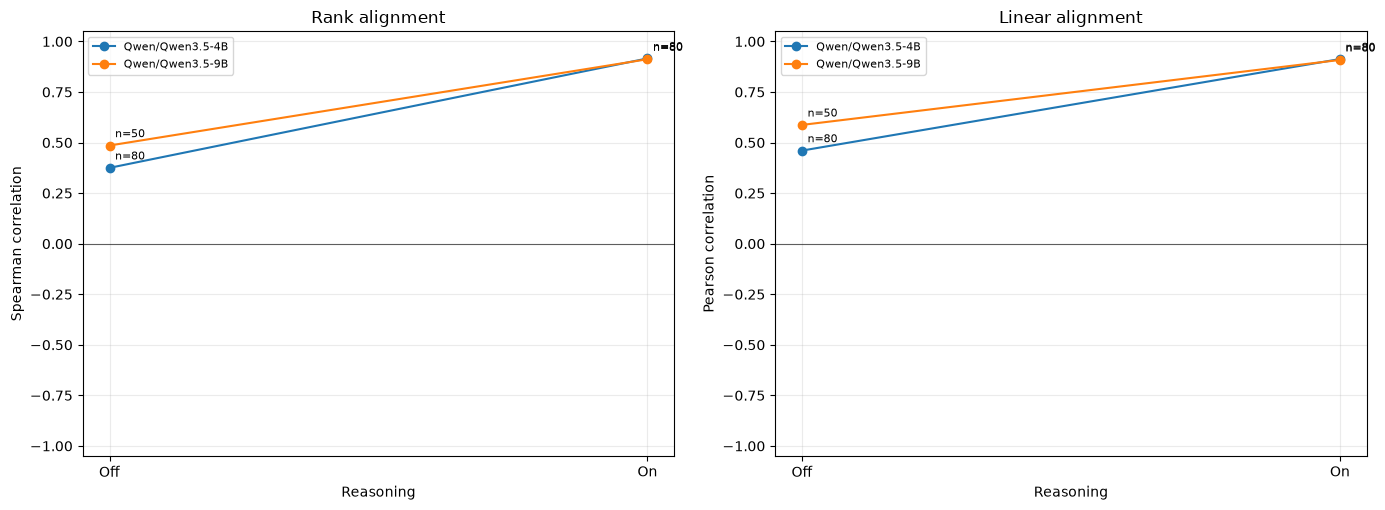

{'Qwen/Qwen3.5-4B': {False: {'n': 80,
   'spearman': 0.3750057488887753,
   'pearson': 0.46036729496165807},
  True: {'n': 80,
   'spearman': 0.9160902582931614,
   'pearson': 0.912919235037237}},
 'Qwen/Qwen3.5-9B': {False: {'n': 50,
   'spearman': 0.48549943036194293,
   'pearson': 0.5872873114251372},
  True: {'n': 80,
   'spearman': 0.9120396665026392,
   'pearson': 0.9085817774376461}}}

In [21]:
correlation_rows_by_model = {
    model_id: {
        reasoning: correlation_summary(rows_at_reasoning(rows, reasoning))
        for reasoning in REASONING_VALUES
    }
    for model_id, rows in balanced_results_by_model.items()
}
fig, (ax_spearman, ax_pearson) = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True)
for model_id, summaries in correlation_rows_by_model.items():
    x_values = [0, 1]
    ax_spearman.plot(
        x_values, [float(summaries[value]["spearman"]) for value in REASONING_VALUES],
        marker="o", label=model_id,
    )
    ax_pearson.plot(
        x_values, [float(summaries[value]["pearson"]) for value in REASONING_VALUES],
        marker="o", label=model_id,
    )
    for axis, key in ((ax_spearman, "spearman"), (ax_pearson, "pearson")):
        for x_value, reasoning in zip(x_values, REASONING_VALUES):
            summary = summaries[reasoning]
            axis.annotate(
                f"n={summary['n']}",
                (x_value, float(summary[key])), xytext=(4, 6),
                textcoords="offset points", fontsize=8,
            )
for axis, title, ylabel in (
    (ax_spearman, "Rank alignment", "Spearman correlation"),
    (ax_pearson, "Linear alignment", "Pearson correlation"),
):
    axis.axhline(0, color="black", linewidth=0.8, alpha=0.6)
    axis.set(
        xlabel="Reasoning", ylabel=ylabel, title=title,
        xticks=[0, 1], xticklabels=["Off", "On"], ylim=(-1.05, 1.05),
    )
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
fig.tight_layout()
plt.show()
correlation_rows_by_model


## Reasoning length, compliance, and completion statistics

Reasoning length is the exact number of generated assistant tokens from the start of the assistant turn through the final colon in the last `ANSWER:` marker. It is `None` when the marker is missing or is not aligned to a token boundary. The plots retain malformed completions and separate compliance from boundary availability.


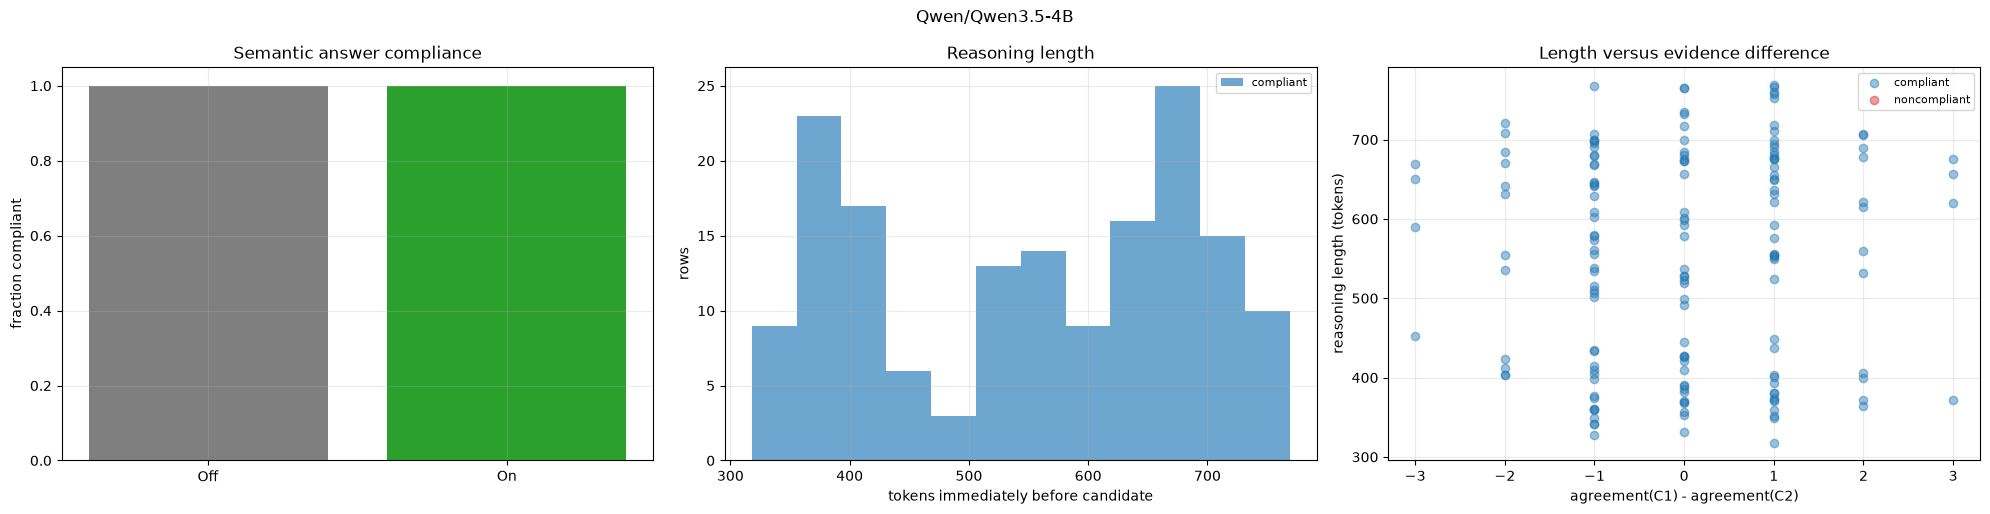

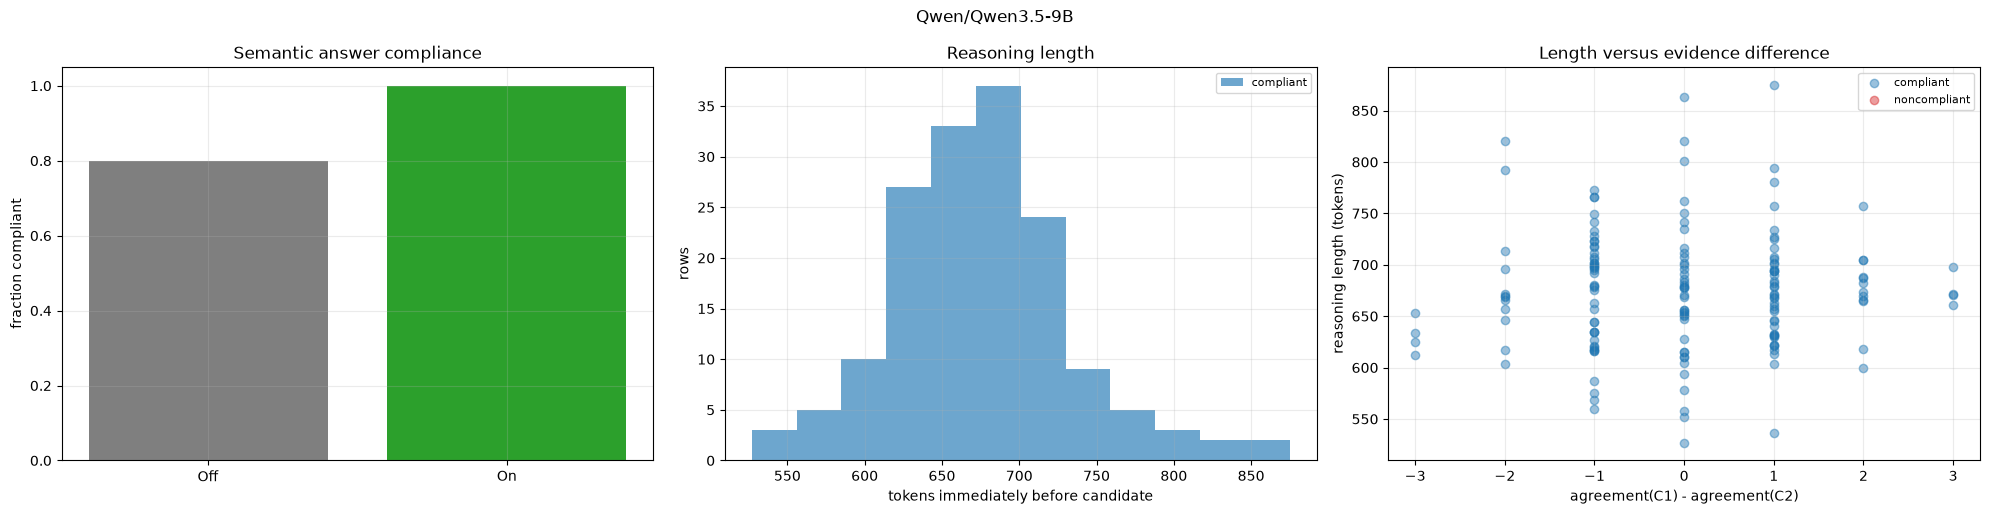

{'Qwen/Qwen3.5-4B': {False: {'rows': 160,
   'semantic_compliance_rate': 1.0,
   'exact_format_compliance_rate': 1.0,
   'answer_marker_rate': 1.0,
   'boundary_available_rate': 1.0,
   'reasoning_length_count': 0,
   'reasoning_length_mean': None,
   'reasoning_length_median': None,
   'reasoning_length_sd': None,
   'reasoning_length_min': None,
   'reasoning_length_max': None,
   'generated_length_mean': 1.0,
   'hit_completion_cap': 0,
   'answer_whitespace_forms': {"'' + candidate + ''": 160},
   'emitted_candidate_token_ids': {'[17]': 80, '[22]': 80},
   'terminal_stop_token_ids': {'248046': 160},
   'compliance_breaks': {'compliant': 160}},
  True: {'rows': 160,
   'semantic_compliance_rate': 1.0,
   'exact_format_compliance_rate': 0.0,
   'answer_marker_rate': 1.0,
   'boundary_available_rate': 1.0,
   'reasoning_length_count': 160,
   'reasoning_length_mean': 551.05625,
   'reasoning_length_median': 567.0,
   'reasoning_length_sd': 134.32545583744542,
   'reasoning_length_min'

In [25]:
def completion_statistics(rows: list[dict[str, object]]) -> dict[str, object]:
    lengths = [
        int(row["reasoning_length_tokens"])
        for row in rows if row["reasoning_length_tokens"] is not None
    ]
    generated_lengths = [len(row["generated_token_ids"]) for row in rows]
    return {
        "rows": len(rows),
        "semantic_compliance_rate": fmean(float(row["semantic_answer_compliance"]) for row in rows),
        "exact_format_compliance_rate": fmean(float(row["exact_answer_format_compliance"]) for row in rows),
        "answer_marker_rate": fmean(float(row["answer_marker_present"]) for row in rows),
        "boundary_available_rate": fmean(
            float(row["answer_boundary_generated_token_count"] is not None) for row in rows
        ),
        "reasoning_length_count": len(lengths),
        "reasoning_length_mean": fmean(lengths) if lengths else None,
        "reasoning_length_median": median(lengths) if lengths else None,
        "reasoning_length_sd": pstdev(lengths) if len(lengths) > 1 else 0.0 if lengths else None,
        "reasoning_length_min": min(lengths) if lengths else None,
        "reasoning_length_max": max(lengths) if lengths else None,
        "generated_length_mean": fmean(generated_lengths),
        "hit_completion_cap": sum(bool(row["completion"]["hit_token_cap"]) for row in rows),
        "answer_whitespace_forms": dict(Counter(
            f"{row['answer_leading_whitespace']!r} + candidate + {row['answer_trailing_whitespace']!r}"
            for row in rows if row["semantic_answer_compliance"]
        )),
        "emitted_candidate_token_ids": dict(Counter(
            str(row["answer_value_generated_token_ids"])
            for row in rows if row["semantic_answer_compliance"]
        )),
        "terminal_stop_token_ids": dict(Counter(
            str(row["completion"].get("terminal_stop_token_id")) for row in rows
        )),
        "compliance_breaks": dict(Counter(row["compliance_break"] or "compliant" for row in rows)),
    }


reasoning_statistics_by_model = {}
for model_id, all_rows in results_by_model.items():
    off_rows = rows_at_reasoning(all_rows, False)
    on_rows = rows_at_reasoning(all_rows, True)
    reasoning_statistics_by_model[model_id] = {
        False: completion_statistics(off_rows),
        True: completion_statistics(on_rows),
    }
    available = [row for row in on_rows if row["reasoning_length_tokens"] is not None]
    compliant_lengths = [
        int(row["reasoning_length_tokens"]) for row in available
        if row["strict_answer_compliance"]
    ]
    broken_lengths = [
        int(row["reasoning_length_tokens"]) for row in available
        if not row["strict_answer_compliance"]
    ]
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.2))
    compliance_rates = [
        fmean(float(row["strict_answer_compliance"]) for row in selected)
        for selected in (off_rows, on_rows)
    ]
    axes[0].bar(["Off", "On"], compliance_rates, color=["tab:grey", "tab:green"])
    axes[0].set(title="Semantic answer compliance", ylabel="fraction compliant", ylim=(0, 1.05))
    bins = min(30, max(5, int(math.sqrt(max(1, len(available))))))
    if compliant_lengths:
        axes[1].hist(compliant_lengths, bins=bins, alpha=0.65, label="compliant")
    if broken_lengths:
        axes[1].hist(broken_lengths, bins=bins, alpha=0.65, label="noncompliant")
    axes[1].set(title="Reasoning length", xlabel="tokens immediately before candidate", ylabel="rows")
    axes[1].legend(fontsize=8)
    for compliant, color, label in ((True, "tab:blue", "compliant"), (False, "tab:red", "noncompliant")):
        selected = [row for row in available if bool(row["strict_answer_compliance"]) is compliant]
        axes[2].scatter(
            [int(row["total_agreement_candidate_1"]) - int(row["total_agreement_candidate_2"]) for row in selected],
            [int(row["reasoning_length_tokens"]) for row in selected],
            alpha=0.45, color=color, label=label,
        )
    axes[2].set(
        title="Length versus evidence difference",
        xlabel="agreement(C1) - agreement(C2)", ylabel="reasoning length (tokens)",
    )
    axes[2].legend(fontsize=8)
    for axis in axes:
        axis.grid(alpha=0.25)
    fig.suptitle(model_id)
    fig.tight_layout()
    plt.show()

reasoning_statistics_by_model


## Raw wide truth tables

One CSV is exported per model and reasoning value. Missing logits remain empty cells, so compliance failures are not silently dropped from the tabular record.


In [23]:
def format_optional(value: object) -> str:
    return "" if value is None else f"{float(value):.8f}"


def raw_truth_table(rows: list[dict[str, object]]) -> tuple[list[str], list[list[str]]]:
    by_key = {
        (int(row["answer_pattern_index"]), int(row["question_set_index"])): row
        for row in rows
    }
    headers = ["answer_pattern", *[f"report_i{i}" for i in range(1, K + 1)]]
    for j in range(1, NUM_QUESTION_SETS + 1):
        headers.extend([
            f"agreement_j{j}_c1", f"agreement_j{j}_c2",
            f"raw_logit_j{j}_c1", f"raw_logit_j{j}_c2",
            f"raw_logit_j{j}_c1_minus_c2", f"has_boundary_logits_j{j}",
        ])
    matrix = []
    for pattern_index, reports in enumerate(answer_patterns(K)):
        pattern = "".join("Y" if report == "YES" else "N" for report in reports)
        output = [pattern, *reports]
        for question_set_index in range(NUM_QUESTION_SETS):
            row = by_key[(pattern_index, question_set_index)]
            output.extend([
                str(row["total_agreement_candidate_1"]),
                str(row["total_agreement_candidate_2"]),
                format_optional(row["candidate_1_raw_logit"]),
                format_optional(row["candidate_2_raw_logit"]),
                format_optional(row["candidate_1_minus_candidate_2_raw_logit"]),
                str(bool(row["pair_has_answer_boundary_logits"])),
            ])
        matrix.append(output)
    return headers, matrix


truth_tables_by_model = {}
for model_id, all_rows in balanced_results_by_model.items():
    truth_tables_by_model[model_id] = {}
    output_dir = EXPERIMENT_ROOT / model_key(model_id)
    for reasoning in REASONING_VALUES:
        headers, matrix = raw_truth_table(rows_at_reasoning(all_rows, reasoning))
        truth_tables_by_model[model_id][reasoning] = {"headers": headers, "rows": matrix}
        path = output_dir / f"agreement_truth_table_reasoning_{reasoning_label(reasoning).lower()}.csv"
        with path.open("w", newline="", encoding="utf-8") as handle:
            writer = csv.writer(handle, lineterminator="\n")
            writer.writerow(headers)
            writer.writerows(matrix)


def display_truth_table(reasoning: bool) -> None:
    for model_id, tables in truth_tables_by_model.items():
        table = tables[reasoning]
        print(f"{model_id} — reasoning {reasoning_label(reasoning)}: {len(table['rows'])} rows")
        display(table["rows"][:2])


truth_widget = reasoning_selector()
truth_output = widgets.interactive_output(display_truth_table, {"reasoning": truth_widget})
display(widgets.VBox([truth_widget, truth_output]))


## Compact completion audit

The audit view exposes the original completion, generated IDs, boundary metadata, and compliance outcome for one row without altering malformed text.


In [24]:
def display_audit_view(reasoning: bool) -> None:
    for model_id, rows in results_by_model.items():
        selected = rows_at_reasoning(rows, reasoning)
        sample = next(
            (row for row in selected if not row["strict_answer_compliance"]),
            selected[0],
        )
        print(f"{model_id} — reasoning {reasoning_label(reasoning)}")
        display({
            "row_id": sample["row_id"],
            "presentation_order": sample["presentation_order"],
            "membership_sets": sample["membership_sets"],
            "observed_reports": sample["observed_reports"],
            "agreement_c1": sample["agreement_candidate_1_by_question"],
            "agreement_c2": sample["agreement_candidate_2_by_question"],
            "full_completion": sample["full_completion"],
            "generated_token_ids": sample["generated_token_ids"],
            "generated_sequence_token_ids": sample["generated_sequence_token_ids"],
            "reasoning_length_tokens": sample["reasoning_length_tokens"],
            "answer_boundary_source": sample["answer_boundary_source"],
            "answer_boundary_generated_token_count": sample["answer_boundary_generated_token_count"],
            "answer_leading_whitespace": repr(sample["answer_leading_whitespace"]),
            "answer_trailing_whitespace": repr(sample["answer_trailing_whitespace"]),
            "answer_leading_whitespace_token_ids": sample["answer_leading_whitespace_token_ids"],
            "answer_value_generated_token_ids": sample["answer_value_generated_token_ids"],
            "answer_trailing_whitespace_token_ids": sample["answer_trailing_whitespace_token_ids"],
            "terminal_stop_token_id": sample["completion"].get("terminal_stop_token_id"),
            "candidate_1_answer_token_ids": sample["candidate_1_answer_token_ids"],
            "candidate_2_answer_token_ids": sample["candidate_2_answer_token_ids"],
            "semantic_answer_compliance": sample["semantic_answer_compliance"],
            "exact_answer_format_compliance": sample["exact_answer_format_compliance"],
            "strict_answer_compliance": sample["strict_answer_compliance"],
            "compliance_break": sample["compliance_break"],
            "answer_boundary_break": sample["answer_boundary_break"],
            "candidate_1_raw_logit": sample["candidate_1_raw_logit"],
            "candidate_2_raw_logit": sample["candidate_2_raw_logit"],
            "activation_path": sample.get("activation_path"),
        })


audit_widget = reasoning_selector()
audit_output = widgets.interactive_output(display_audit_view, {"reasoning": audit_widget})
display(widgets.VBox([audit_widget, audit_output]))
